# <center>Clustering Analysis<center>

<p>Team Name:
<p>Student Names:

## Instructions
Use generic coding style unless hard-coded values are really necessary.<br>
Your code must be efficient and use self-explanatory naming.<br>
Use appropriate Python library methods for each task instead of using loops.<br>
Run your entire code and save. Then submit this <b>saved</b> copy.

## Imports

In [1]:
import os, re
import numpy as np
import pandas as pd
import tifffile as tfl
from scipy.ndimage import uniform_filter, sobel
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


## Read Data

In [2]:
path_to_data = '../Data/zebrafish-data'

def load_tiff_stacks(directory: str, n: int):
    '''Load tiff stacks as 3D numpy arrays into stack_array.'''
    stack_array = []
    
    for i in range(n):
        stack = tfl.imread(f'{directory}/ZS-{i+1}.tif').astype(float)
        stack_array.append(stack)

    return stack_array

def normalize_all_tiff_stacks(tiff_stack_array):
    normalized_tiff_stacks = []
    
    for i in range(len(tiff_stack_array)):
        normalized_tiff_stacks.append(normalize_tiff_stack(tiff_stack_array[i]))

    return normalized_tiff_stacks


def normalize_tiff_stack(tiff_stack):
    '''Normalize tiff stack in range 0-1.'''
    norm_tiff_stack = tiff_stack / tiff_stack.max()
    return norm_tiff_stack 

def get_all_pixel_tables(tif_stack_array):
    pixel_tables = []

    for i in range(len(tif_stack_array)):
        pixel_tables.append(stack_to_pixel_table(tif_stack_array[i]))

    return pixel_tables

def stack_to_pixel_table(tiff_array):
    depth, height, width = tiff_array.shape

    # Create coordinate grid
    z, y, x = np.meshgrid(
        np.arange(depth),
        np.arange(height),
        np.arange(width),
        indexing = 'ij'
    )

    # Flatten to build table
    pixel_table = np.column_stack((
        z.flatten(), # z coordinate
        y.flatten(), # y coordinate
        x.flatten(), # x coordinate
        tiff_array.flatten() # intensity
    ))

    return pixel_table

def stacks_to_dataframe(stacks_2d, group_label):
    '''Convert list of 2D pixel tables to one DataFrame.'''
    df_all = pd.DataFrame()
    
    for i, pixel_table in enumerate(stacks_2d):
        df = pd.DataFrame(pixel_table, columns=['z', 'y', 'x', 'intensity'])
        df[['z', 'y', 'x']] = df[['z', 'y', 'x']].astype(int) 
        df['fish_id'] = i + 1
        df['group'] = group_label
        df_all = pd.concat([df_all, df], ignore_index=True)
        
    return df_all

def build_group_dataframe(directory: str, n: int, group_label='control'):
    # Load stacks
    stacks = load_tiff_stacks(directory, n)
    
    # Normalize stacks
    stacks_norm = normalize_all_tiff_stacks(stacks)
    
    # Convert to 2D pixel tables
    stacks_2d = get_all_pixel_tables(stacks_norm)
    
    # Build a combined singular Pandas DataFrame
    df = stacks_to_dataframe(stacks_2d, group_label)
    
    return df

In [3]:
def local_std_2d(img2d, k=3):
    """Fast local std using mean and mean-of-squares (reflect padding)."""
    m = uniform_filter(img2d, size=k, mode='reflect')
    m2 = uniform_filter(img2d*img2d, size=k, mode='reflect')
    var = m2 - m*m
    var[var < 0] = 0.0
    return np.sqrt(var).astype(np.float32)

def compute_texture_for_stack(stack3d, k=3):
    """Compute local std per z-slice; returns float32 array same shape as stack3d."""
    depth = stack3d.shape[0]
    tex = np.empty_like(stack3d, dtype=np.float32)
    for z in range(depth):
        tex[z] = local_std_2d(stack3d[z], k=k)
    return tex

def compute_gradient_magnitude_stack(stack3d):
    """Compute Sobel-based 2D gradient magnitude per z-slice."""
    depth = stack3d.shape[0]
    grad = np.empty_like(stack3d, dtype=np.float32)
    for z in range(depth):
        gx = sobel(stack3d[z], axis=1, mode='reflect')  # x-direction
        gy = sobel(stack3d[z], axis=0, mode='reflect')  # y-direction
        grad[z] = np.hypot(gx, gy).astype(np.float32)
    return grad

def stack_to_pixel_table_with_features(tiff_array, texture_array=None, gradient_array=None):
    """Return (pixel_table, colnames). Non-destructive: keeps original stack_to_pixel_table intact."""
    depth, height, width = tiff_array.shape
    z, y, x = np.meshgrid(
        np.arange(depth),
        np.arange(height),
        np.arange(width),
        indexing='ij'
    )
    cols = [z.flatten(), y.flatten(), x.flatten(), tiff_array.flatten()]
    col_names = ['z', 'y', 'x', 'intensity']
    if texture_array is not None:
        cols.append(texture_array.flatten()); col_names.append('texture')
    if gradient_array is not None:
        cols.append(gradient_array.flatten()); col_names.append('gradient')
    pixel_table = np.column_stack(cols)
    return pixel_table, col_names

def build_group_dataframe_with_features(directory: str, n: int, group_label='control', tex_k=3):
    """Load stacks, normalize, compute texture+grad, convert to dataframe with feature columns."""
    stacks = load_tiff_stacks(directory, n)
    stacks_norm = normalize_all_tiff_stacks(stacks)
    # compute features per stack
    texture_stacks = [compute_texture_for_stack(s, k=tex_k) for s in stacks_norm]
    gradient_stacks = [compute_gradient_magnitude_stack(s) for s in stacks_norm]
    # convert each stack into pixel_table with feature columns and then to DataFrame
    df_all = pd.DataFrame()
    for i, s in enumerate(stacks_norm):
        table, colnames = stack_to_pixel_table_with_features(s, texture_stacks[i], gradient_stacks[i])
        df = pd.DataFrame(table, columns=colnames)
        df[['z','y','x']] = df[['z','y','x']].astype(int)
        df['fish_id'] = i + 1
        df['group'] = group_label
        df_all = pd.concat([df_all, df], ignore_index=True)
    return df_all


In [4]:
num_in_control = 3
control_df = build_group_dataframe('../Data/zebrafish-data', num_in_control, 'control')

fish_cat1 = []
num_fish_cat1 = 0

fish_cat2 = []
num_fish_cat2 = 0

In [5]:
print(control_df.head())
print()
print(control_df.dtypes)

   z  y  x  intensity  fish_id    group
0  0  0  0   0.024174        1  control
1  0  0  1   0.021707        1  control
2  0  0  2   0.024174        1  control
3  0  0  3   0.025160        1  control
4  0  0  4   0.025160        1  control

z              int64
y              int64
x              int64
intensity    float64
fish_id        int64
group         object
dtype: object


In [6]:
num_in_control = 1  # test on a single stack first
test_df = build_group_dataframe_with_features('../Data/zebrafish-data', num_in_control, 'control', tex_k=5)
print(test_df.head())
print(test_df.dtypes)

   z  y  x  intensity   texture  gradient  fish_id    group
0  0  0  0   0.024174  0.001944  0.005753        1  control
1  0  0  1   0.021707  0.001851  0.012343        1  control
2  0  0  2   0.024174  0.001835  0.014668        1  control
3  0  0  3   0.025160  0.002023  0.006619        1  control
4  0  0  4   0.025160  0.001740  0.006318        1  control
z              int64
y              int64
x              int64
intensity    float64
texture      float64
gradient     float64
fish_id        int64
group         object
dtype: object


In [7]:
viz_df = test_df.sample(50_000, random_state=451) if len(test_df) > 50_000 else test_df.copy() #  <---- For visualization on a smaller subset of data
# viz_df = test_df.copy()
numeric_cols = ['intensity', 'texture', 'gradient', 'z', 'y', 'x']

## Visual Exploration of Data

In [8]:
# Create a folder to save figures (relative path)
fig_dir = os.path.join('.', 'Figures')
os.makedirs(fig_dir, exist_ok=True)
print(f"Saving figures to: {fig_dir}")

Saving figures to: ./Figures


### Histograms

Saved: ./Figures/histograms.png


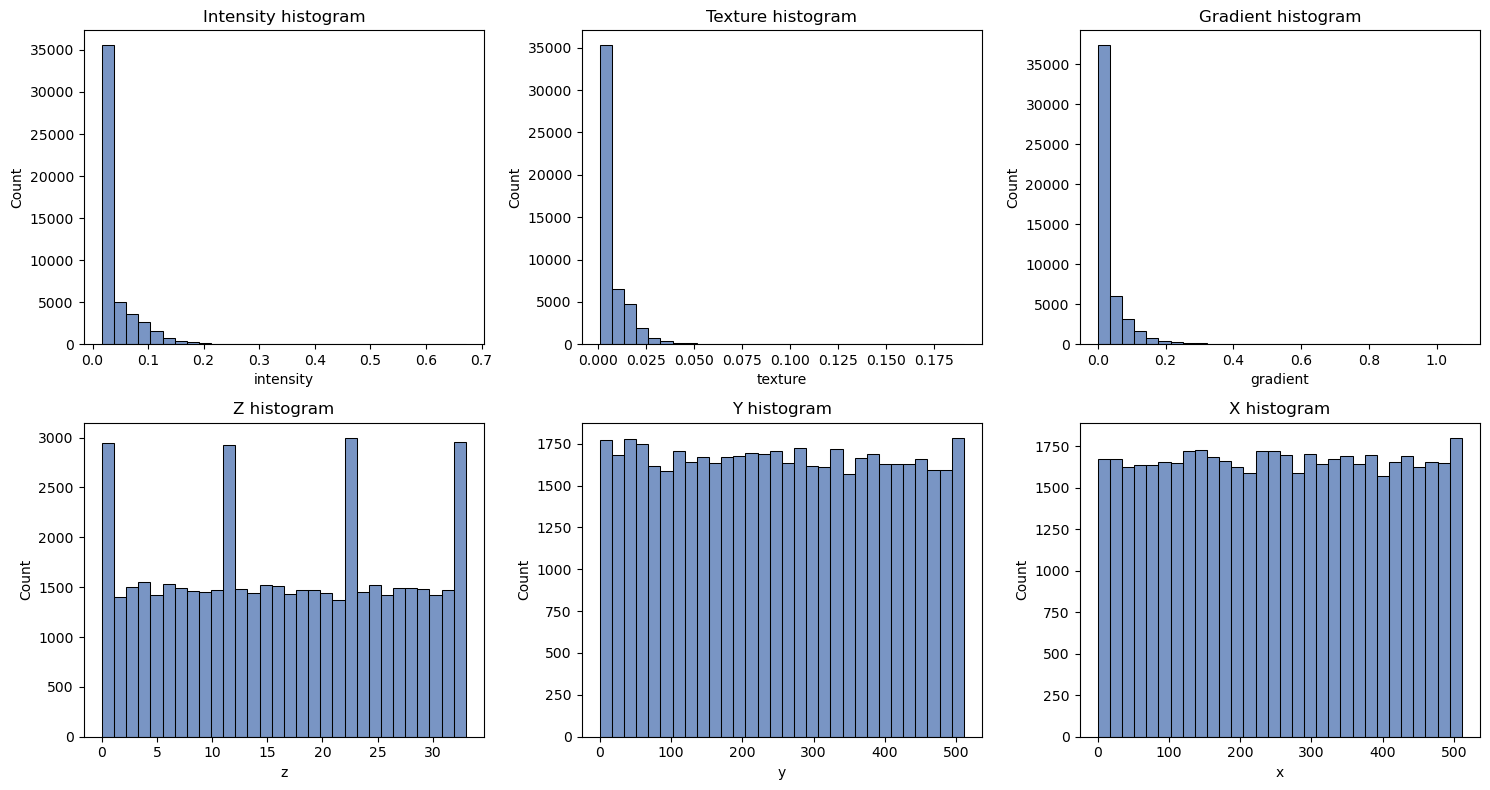

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for col, ax in zip(numeric_cols, axes):
    sns.histplot(viz_df[col], bins=30, ax=ax, color='#4c72b0')
    ax.set_title(f'{col.title()} histogram')
plt.tight_layout()
out_path = os.path.join(fig_dir, 'histograms.png')
fig.savefig(out_path, dpi=300, bbox_inches='tight')
print(f"Saved: {out_path}")
plt.show()
plt.close(fig)

### Distributions

Saved: ./Figures/densities.png


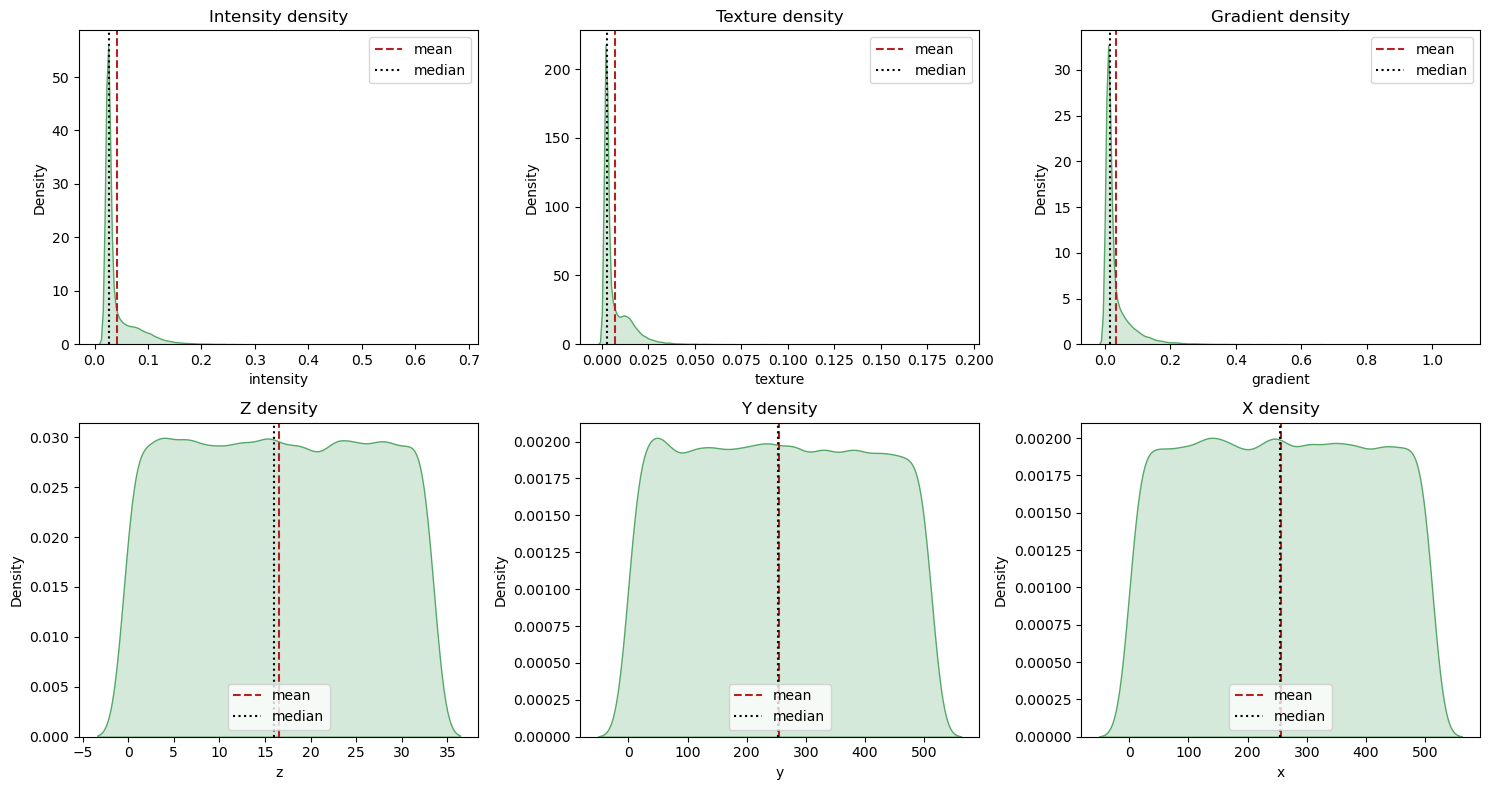

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for col, ax in zip(numeric_cols, axes):
    sns.kdeplot(viz_df[col], fill=True, ax=ax, color='#55a868')
    ax.axvline(viz_df[col].mean(), ls='--', color='firebrick', label='mean')
    ax.axvline(viz_df[col].median(), ls=':', color='black', label='median')
    ax.legend()
    ax.set_title(f'{col.title()} density')
plt.tight_layout()
out_path = os.path.join(fig_dir, 'densities.png')
fig.savefig(out_path, dpi=300, bbox_inches='tight')
print(f"Saved: {out_path}")
plt.show()
plt.close(fig)

### Box-Whisker Plots

Saved: ./Figures/boxplots.png


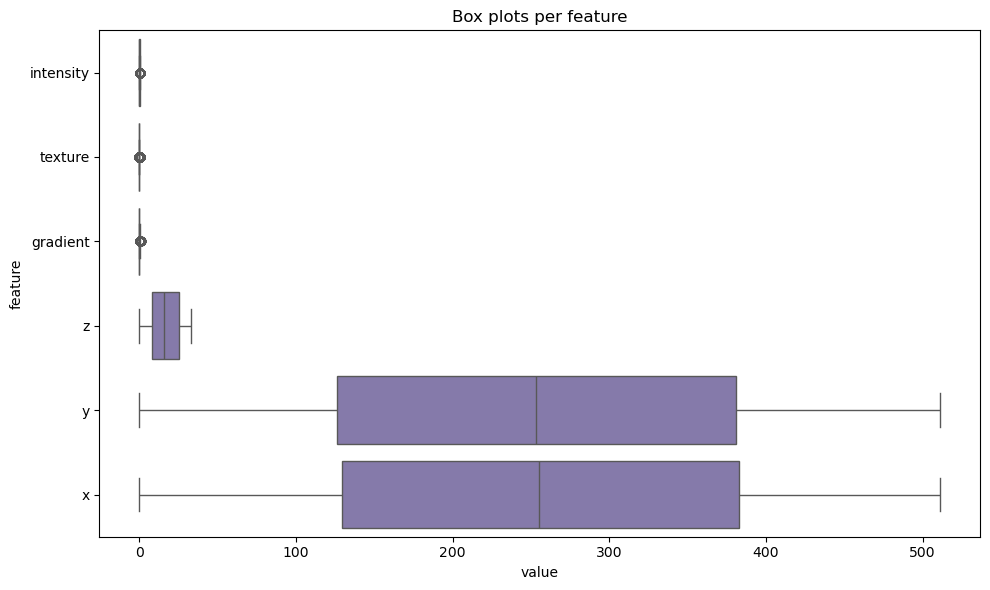

In [11]:
melted = viz_df[numeric_cols].melt(var_name='feature', value_name='value')
plt.figure(figsize=(10, 6))
sns.boxplot(data=melted, x='value', y='feature', orient='h', color='#8172b2')
plt.title('Box plots per feature')
plt.tight_layout()
fig = plt.gcf()
out_path = os.path.join(fig_dir, 'boxplots.png')
fig.savefig(out_path, dpi=300, bbox_inches='tight')
print(f"Saved: {out_path}")
plt.show()
plt.close(fig)

### Violin Plots

Saved: ./Figures/violins.png


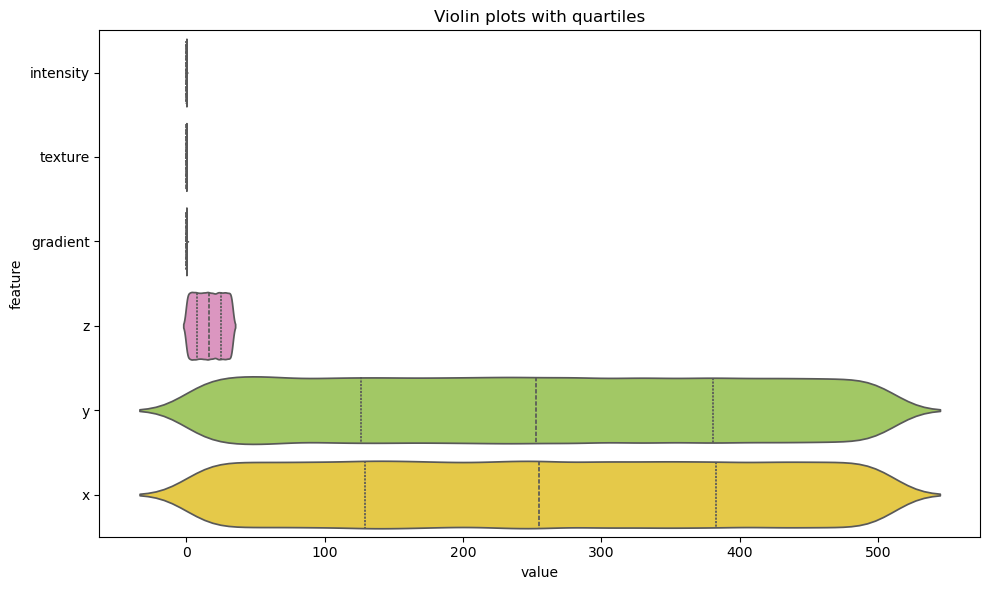

In [12]:
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=melted,
    x='value', y='feature',
    hue='feature', legend=False,  # fix
    orient='h', inner='quartile',
    palette='Set2'
)
plt.title('Violin plots with quartiles')
plt.tight_layout()
fig = plt.gcf()
out_path = os.path.join(fig_dir, 'violins.png')
fig.savefig(out_path, dpi=300, bbox_inches='tight')
print(f"Saved: {out_path}")
plt.show()
plt.close(fig)

## Data Quality & Cleaning

Instruction: Add a comment for each method

## Handling Redundancy

### X-square Test

### Correlation Analysis

### Visual Exploration (scatter-plot matrix)

## Dimensionality Reduction

### PCA

## Discretization

### Histogram of Discretized Attribute

### X-square Test of Discretized Attributes

### Visual Exploration (scatter-plot matrix) of Discretized Attributes

## Feature Selection/Generation

### Select Features

### Generate Features

# Generate Clusters

## K-means

## Hierarchical

# Evaluation of Clusters

See instructions provided in the report template

## <center> REFERENCES </center>
List resources (book, internet page, etc.) that you used to complete this challenge.